<a href="https://colab.research.google.com/github/Sakhiur2022/QSAR-modeling-for-DHFR-TS/blob/main/notebooks/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Computational Drug Discovery - Exploratory Data Analysis**

Sakhiur Rahman

In this notebook, I will be performing Descriptor Calculation and Exploratory Data Analysis.

---

## **Install rdkit**

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 27.7 MB/s eta 0:00:00


## **Load bioactivity data**

In [11]:
!wget https://github.com/Sakhiur2022/QSAR-modeling-for-DHFR-TS/raw/refs/heads/main/data/preprocessed/bioactivity_preprocessed_data.csv

--2026-06-12 04:41:21--  https://github.com/Sakhiur2022/QSAR-modeling-for-DHFR-TS/raw/refs/heads/main/data/preprocessed/bioactivity_preprocessed_data.csv
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Sakhiur2022/QSAR-modeling-for-DHFR-TS/refs/heads/main/data/preprocessed/bioactivity_preprocessed_data.csv [following]
--2026-06-12 04:41:21--  https://raw.githubusercontent.com/Sakhiur2022/QSAR-modeling-for-DHFR-TS/refs/heads/main/data/preprocessed/bioactivity_preprocessed_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 76537 (75K) [text/plain]
Saving to: ‘bioactivity_preprocessed_data.cs

In [9]:
import pandas as pd

In [12]:
dataset_preprocessed = pd.read_csv('bioactivity_preprocessed_data.csv')

## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [6]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [7]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [13]:
dataset_preprocessed_lipinski = lipinski(dataset_preprocessed.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [15]:
dataset_preprocessed_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,318.377,1.82000,2.0,7.0
1,288.351,2.02920,2.0,6.0
2,274.324,1.63910,2.0,6.0
3,426.520,4.69822,2.0,6.0
4,304.350,1.56602,2.0,7.0
...,...,...,...,...
1069,278.743,1.88630,3.0,5.0
1070,278.743,1.88630,3.0,5.0
1071,348.406,3.15940,3.0,5.0
1072,312.421,1.92010,2.0,6.0


In [16]:
dataset_preprocessed

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,pChEMBL_value
0,CHEMBL419055,CCc1nc(N)nc(N)c1Cc1cc(OC)c(OC)c(OC)c1,active,4.300,8.37
1,CHEMBL419231,CCCOc1cc(Cc2cnc(N)nc2N)ccc1OC,active,144.400,6.84
2,CHEMBL332013,CCOc1ccc(Cc2cnc(N)nc2N)cc1OC,active,187.400,6.73
3,CHEMBL279948,Cc1nc(N)nc(N)c1Cc1ccc(OCc2ccccc2)c(OCc2ccccc2)c1,active,241.000,6.62
4,CHEMBL325533,COc1cc(Cc2c(C)nc(N)nc2N)cc(OC)c1OC,active,520.300,6.28
...,...,...,...,...,...
1069,CHEMBL422005,Nc1nc(N)c(-c2cccc(Cl)c2)c(CCCO)n1,active,29.000,7.54
1070,CHEMBL422005,Nc1nc(N)c(-c2cccc(Cl)c2)c(CCCO)n1,intermediate,1900.000,5.72
1071,CHEMBL5499545,CCc1nc(N)nc(N)c1Cc1ccc(-c2cccc(C(=O)O)c2)cc1,active,0.290,9.54
1072,CHEMBL5822647,CCCc1nc(N)nc(N)c1N1CCN(c2ccccc2)CC1,active,14.100,7.85


Now, let's combine the 2 DataFrame

In [17]:
dataset_preprocessed_lipinski_combined = pd.concat([dataset_preprocessed,dataset_preprocessed_lipinski], axis=1)

In [18]:
dataset_preprocessed_lipinski_combined

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,pChEMBL_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL419055,CCc1nc(N)nc(N)c1Cc1cc(OC)c(OC)c(OC)c1,active,4.300,8.37,318.377,1.82000,2.0,7.0
1,CHEMBL419231,CCCOc1cc(Cc2cnc(N)nc2N)ccc1OC,active,144.400,6.84,288.351,2.02920,2.0,6.0
2,CHEMBL332013,CCOc1ccc(Cc2cnc(N)nc2N)cc1OC,active,187.400,6.73,274.324,1.63910,2.0,6.0
3,CHEMBL279948,Cc1nc(N)nc(N)c1Cc1ccc(OCc2ccccc2)c(OCc2ccccc2)c1,active,241.000,6.62,426.520,4.69822,2.0,6.0
4,CHEMBL325533,COc1cc(Cc2c(C)nc(N)nc2N)cc(OC)c1OC,active,520.300,6.28,304.350,1.56602,2.0,7.0
...,...,...,...,...,...,...,...,...,...
1069,CHEMBL422005,Nc1nc(N)c(-c2cccc(Cl)c2)c(CCCO)n1,active,29.000,7.54,278.743,1.88630,3.0,5.0
1070,CHEMBL422005,Nc1nc(N)c(-c2cccc(Cl)c2)c(CCCO)n1,intermediate,1900.000,5.72,278.743,1.88630,3.0,5.0
1071,CHEMBL5499545,CCc1nc(N)nc(N)c1Cc1ccc(-c2cccc(C(=O)O)c2)cc1,active,0.290,9.54,348.406,3.15940,3.0,5.0
1072,CHEMBL5822647,CCCc1nc(N)nc(N)c1N1CCN(c2ccccc2)CC1,active,14.100,7.85,312.421,1.92010,2.0,6.0


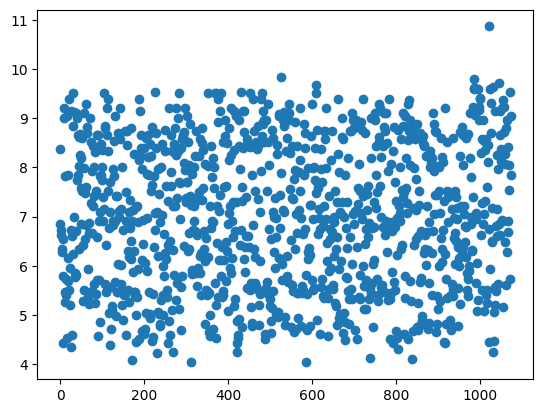

In [20]:
import matplotlib.pyplot as plt
plt.scatter(dataset_preprocessed_lipinski_combined.index,dataset_preprocessed_lipinski_combined['pChEMBL_value'])

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [22]:
import seaborn as sns
sns.set(style='ticks')

### **Frequency plot of the 2 bioactivity classes**

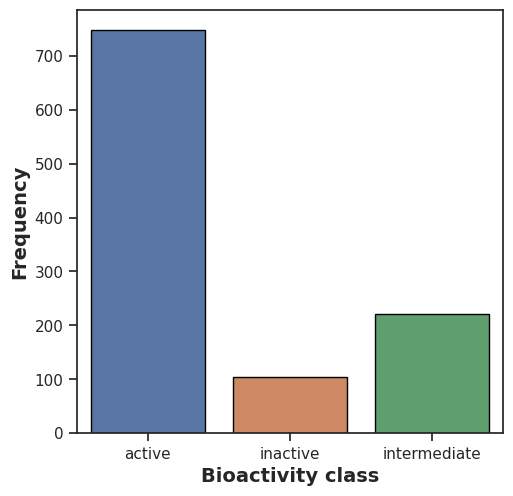

In [50]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=dataset_preprocessed_lipinski_combined, edgecolor='black',hue='bioactivity_class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')
plt.savefig("plot_bioactivity_class.png", dpi=300, bbox_inches="tight")

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

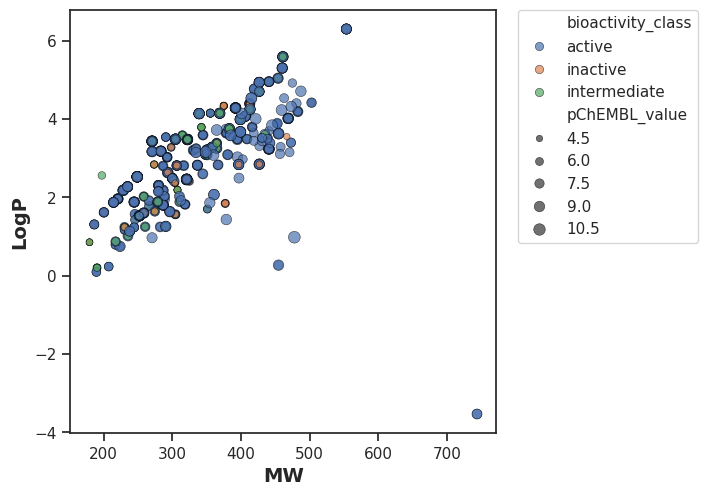

In [52]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=dataset_preprocessed_lipinski_combined, hue='bioactivity_class', size='pChEMBL_value', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')
plt.savefig('plot_MW_vs_LogP.png',dpi=300,bbox_inches="tight")

### **Box plots**

#### **pChEMBL value**

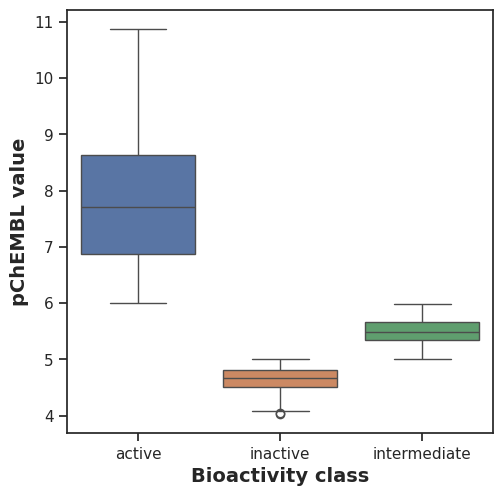

In [53]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pChEMBL_value', data = dataset_preprocessed_lipinski_combined,hue='bioactivity_class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pChEMBL value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')
plt.savefig('plot_pChEMBL.png',dpi=30,bbox_inches="tight")

**Statistical analysis | Mann-Whitney U Test**

In [31]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives, intermediates, and inactives
  selection = [descriptor, 'bioactivity_class']
  df = dataset_preprocessed_lipinski_combined[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [32]:
mannwhitney('pChEMBL_value')

,Descriptor,Statistics,p,alpha,Interpretation
0,pChEMBL_value,78540.0,5.861154e-62,0.05,Different distribution (reject H0)


#### **MW**

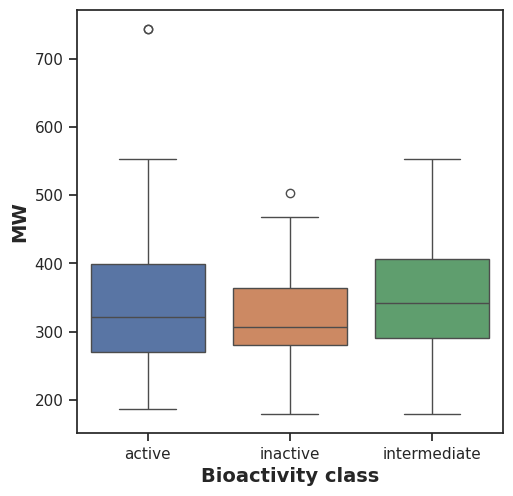

In [54]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data =dataset_preprocessed_lipinski_combined,hue='bioactivity_class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')
plt.savefig('plot_MW.png',dpi=300,bbox_inches='tight')

In [38]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,42360.5,0.19114,0.05,Same distribution (fail to reject H0)


#### **LogP**

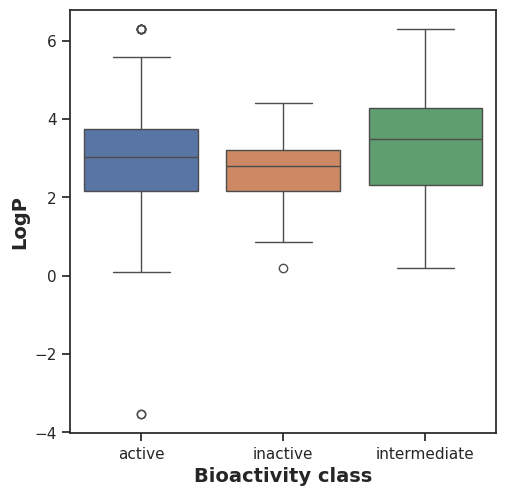

In [39]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = dataset_preprocessed_lipinski_combined,hue='bioactivity_class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [40]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,46579.0,0.00199,0.05,Different distribution (reject H0)


#### **NumHDonors**

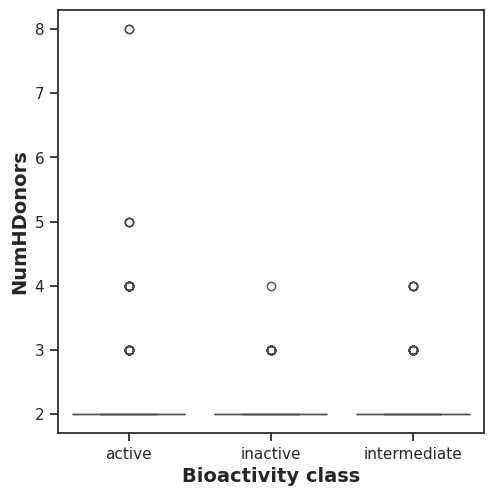

In [41]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data =dataset_preprocessed_lipinski_combined,hue='bioactivity_class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [42]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,33648.5,3.428906e-07,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

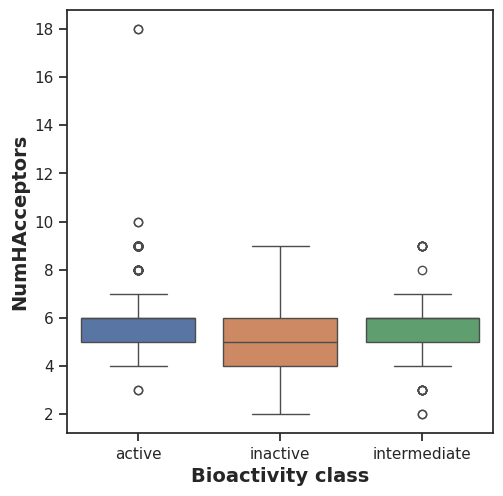

In [44]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = dataset_preprocessed_lipinski_combined, hue='bioactivity_class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [45]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,49182.5,0.000015,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pChEMBL values**

Taking a look at pChEMBL values, the **actives**, **inactives**, and **intermediates** displayed ***statistically significant difference***, which is to be expected since threshold value were used to define actives, intermediates, and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), MW exhibited ***no difference*** between the **actives**, **inactives**, and **intermediate** while the other 3 descriptors (LogP, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [46]:
! zip -r results.zip . -i *.csv *.pdf

  adding: plot_LogP.pdf (deflated 37%)
  adding: mannwhitneyu_pChEMBL_value.csv (deflated 8%)
  adding: plot_MW.pdf (deflated 36%)
  adding: mannwhitneyu_MW.csv (deflated 7%)
  adding: mannwhitneyu_LogP.csv (deflated 8%)
  adding: plot_NumHAcceptors.pdf (deflated 37%)
  adding: plot_bioactivity_class.pdf (deflated 36%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 11%)
  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: plot_ic50.pdf (deflated 36%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: plot_MW_vs_LogP.pdf (deflated 4%)


In [ ]:
! zip -r screenshots.zip . -i *.png